# we are going to use generative models to predict not only the energy, but other important features. 

Our input: 
for epoch in total iterations:

> 1. NXM matrix where N is the number of hours we are considering, M is the number of features that are highly correlated and are numbers. 
> 2. Generator: We can use either a DNN, CNN or transformers
> 3. Output: G(NxM) = 1xM -> which means it predicts the features.
> 4. activation function for each layer is dependant on our prior knowledge of our feature.  
> 5. During training: the loss is between the prediction and the N+1 th hour.

Finally: after the training, we will move to the right by one hour and train on the next matrix. This goes on and on.  

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
path = '/data/hereon/wp/user/hailudaw/git_folders/paper_selfphish/smrl/forcast/participant_package/work/output/audit_table.csv'
df = pd.read_csv(path)
df.keys()

Index(['timestamp', 'power_kw', 'active_container_count',
       'mean_temperature_setpoint_c', 'mean_temperature_ambient_c',
       'mean_temperature_return_c', 'mean_temperature_supply_c',
       'mean_stack_tier', 'share_hardware_decosiiic',
       'share_hardware_decosiiid', 'share_hardware_decosiiid1',
       'share_hardware_decosiiie', 'share_hardware_decosiiif',
       'share_hardware_decosiiig', 'share_hardware_decosiiih',
       'share_hardware_decosiiij', 'share_hardware_decosva',
       'share_hardware_decosvb', 'share_hardware_ml2i', 'share_hardware_ml3',
       'share_hardware_ml5', 'share_hardware_mp3000a', 'share_hardware_mp4000',
       'share_hardware_mpc2000', 'share_hardware_mpc2000id',
       'share_hardware_rccu5', 'share_hardware_scc6',
       'share_container_size_20.0', 'share_container_size_40.0',
       'share_container_size_45.0', 'share_container_size_null',
       'share_stack_tier_1', 'share_stack_tier_2', 'share_stack_tier_3',
       'share_stack_tier_unk

In [15]:
# do the correlation for the power_kw vs others and rank them in order of correlation
correlations = {}
for column in df.columns:
    if column != 'source_timestamp_utc' and column != 'effective_timestamp_utc' or column != 'timestamp':
        try:
            corr = df['power_kw'].corr(df[column])
            correlations[column] = corr
        except Exception as e:
            print(f"Could not compute correlation between power_kw and {column}: {e}")
#sort the correlations in descending order
sorted_correlations = dict(sorted(correlations.items(), key=lambda item: abs(item[1]), reverse=True))
# remove the weak correlation which are below 0.2
strong_correlations = {k: v for k, v in sorted_correlations.items() if abs(v) >= 0.4}
strong_correlations

Could not compute correlation between power_kw and timestamp: could not convert string to float: '2025-01-01 00:00:00'
Could not compute correlation between power_kw and imputation_method: could not convert string to float: 'observed'
Could not compute correlation between power_kw and timestamp_utc: could not convert string to float: '2025-01-01T00:00:00Z'
Could not compute correlation between power_kw and source_timestamp_utc: could not convert string to float: '2025-01-01T00:00:00Z'
Could not compute correlation between power_kw and season_bucket: could not convert string to float: 'winter'


/data/hereon/wp/user/hailudaw/mamba/envs/smrl/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/data/hereon/wp/user/hailudaw/mamba/envs/smrl/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'power_kw': np.float64(1.0),
 'active_container_count': np.float64(0.7945540282802586),
 'share_stack_tier_1': np.float64(-0.6005406355039745),
 'mean_stack_tier': np.float64(0.5672143807643095),
 'share_stack_tier_3': np.float64(0.48840156794970485),
 'share_stack_tier_2': np.float64(0.46842406411178167),
 'mean_ambient_minus_setpoint_c': np.float64(0.4100055605723357)}

In [16]:
# our new data
new_df = df[ ['timestamp']+['power_kw']+list(strong_correlations.keys())]
# add a new column timeid for integer
new_df['timeid'] = range(len(new_df))
# if there is a doubled column, remove it   
new_df = new_df.loc[:,~new_df.columns.duplicated()]
new_df

/tmp/ipykernel_2637643/3165440733.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['timeid'] = range(len(new_df))


,timestamp,power_kw,active_container_count,share_stack_tier_1,mean_stack_tier,share_stack_tier_3,share_stack_tier_2,mean_ambient_minus_setpoint_c,timeid
0,2025-01-01 00:00:00,843.247345,425.0,0.461176,1.760000,0.221176,0.317647,7.537608,0
1,2025-01-01 01:00:00,866.865919,425.0,0.461176,1.760000,0.221176,0.317647,8.104608,1
2,2025-01-01 02:00:00,865.292780,425.0,0.461176,1.760000,0.221176,0.317647,8.418302,2
3,2025-01-01 03:00:00,875.907910,425.0,0.461176,1.760000,0.221176,0.317647,8.563702,3
4,2025-01-01 04:00:00,873.150000,425.0,0.461176,1.760000,0.221176,0.317647,9.103969,4
...,...,...,...,...,...,...,...,...,...
8978,2026-01-10 02:00:00,978.744163,598.0,0.418060,1.834448,0.252508,0.329431,-0.779816,8978
8979,2026-01-10 03:00:00,1004.226512,629.0,0.400636,1.869010,0.270270,0.324324,-1.320647,8979
8980,2026-01-10 04:00:00,1028.173913,630.0,0.401587,1.868045,0.269841,0.326984,-1.380439,8980
8981,2026-01-10 05:00:00,1027.478987,638.0,0.404389,1.863636,0.268025,0.327586,-1.720906,8981


In [189]:
batch_size = 1
batches = []
test = []
# training data is all data that don't have 2026 in their timestamp, which is the last 24 hours of data
train_data = new_df[~new_df['timestamp'].str.contains('2026')]
test_data = new_df[new_df['timestamp'].str.contains('2026')]
for start in range(0, len(train_data) - batch_size + 1, 1):
    batch = train_data.iloc[start:start + batch_size]
    timestamp = batch['timestamp']
    timeid = batch['timeid']
    batch = batch.drop(columns=['timestamp', 'timeid'])
    batches.append(batch.values)
    print(f"Batch {len(batches)-1} with timestamp {timestamp.values[0]} and timeid {timeid.values[0]}")
batches[0]

Batch 0 with timestamp 2025-01-01 00:00:00 and timeid 0
Batch 1 with timestamp 2025-01-01 01:00:00 and timeid 1
Batch 2 with timestamp 2025-01-01 02:00:00 and timeid 2
Batch 3 with timestamp 2025-01-01 03:00:00 and timeid 3
Batch 4 with timestamp 2025-01-01 04:00:00 and timeid 4
Batch 5 with timestamp 2025-01-01 05:00:00 and timeid 5
Batch 6 with timestamp 2025-01-01 06:00:00 and timeid 6
Batch 7 with timestamp 2025-01-01 07:00:00 and timeid 7
Batch 8 with timestamp 2025-01-01 08:00:00 and timeid 8
Batch 9 with timestamp 2025-01-01 09:00:00 and timeid 9
Batch 10 with timestamp 2025-01-01 10:00:00 and timeid 10
Batch 11 with timestamp 2025-01-01 11:00:00 and timeid 11
Batch 12 with timestamp 2025-01-01 12:00:00 and timeid 12
Batch 13 with timestamp 2025-01-01 13:00:00 and timeid 13
Batch 14 with timestamp 2025-01-01 14:00:00 and timeid 14
Batch 15 with timestamp 2025-01-01 15:00:00 and timeid 15
Batch 16 with timestamp 2025-01-01 16:00:00 and timeid 16
Batch 17 with timestamp 2025-01-01

array([[8.43247345e+02, 4.25000000e+02, 4.61176471e-01, 1.76000000e+00,
        2.21176471e-01, 3.17647059e-01, 7.53760784e+00]])

In [18]:
test_data.head()

,timestamp,power_kw,active_container_count,share_stack_tier_1,mean_stack_tier,share_stack_tier_3,share_stack_tier_2,mean_ambient_minus_setpoint_c,timeid
8760,2026-01-01 00:00:00,943.319084,556.0,0.431655,1.794964,0.226619,0.341727,4.899745,8760
8761,2026-01-01 01:00:00,929.788496,555.0,0.430631,1.796396,0.227027,0.342342,4.412039,8761
8762,2026-01-01 02:00:00,929.394377,555.0,0.430631,1.796396,0.227027,0.342342,3.889201,8762
8763,2026-01-01 03:00:00,935.284053,555.0,0.430631,1.796396,0.227027,0.342342,3.840495,8763
8764,2026-01-01 04:00:00,938.494546,554.0,0.431408,1.796029,0.227437,0.341155,4.073375,8764


In [177]:
batch_size =1
stride = batch_size
look_back = 24
train_loader_batch_size = 128

batches = []

train_data = new_df[~new_df['timestamp'].str.contains('2026')].reset_index(drop=True)
test_data = new_df[new_df['timestamp'].str.contains('2026')].reset_index(drop=True)

for start in range(0, len(train_data) - batch_size + 1, stride):
    batch = train_data.iloc[start:start + batch_size]
    batch = batch.drop(columns=['timestamp', 'timeid'])
    batches.append(batch.values)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

config = {
    'input_size': 1,
    'output_size': 1,
    'hidden_size': 16,
    'num_epochs': 1200,
    'learning_rate': 0.001
}

feature_model_config = {
    'input_size': batches[0].shape[1] - 1,
    'output_size': 1,
    'hidden_size': batches[0].shape[1] - 1,
    'num_epochs': 1200,
    'learning_rate': 0.001
}

def generator_model_architecture(config):
    class Generator(nn.Module):
        def __init__(self, config):
            super().__init__()
            self.fc1 = nn.Linear(config['input_size'], config['hidden_size'])
            self.fc3 = nn.Linear(config['hidden_size'], config['output_size'])
            self.relu = nn.ReLU()

        def forward(self, x):
            x = self.relu(self.fc1(x))
            x = self.fc3(x)
            return x

    return Generator(config)

def feature_model_architecture(config):
    class FeatureModel(nn.Module):
        def __init__(self, config):
            super().__init__()
            self.fc1 = nn.Linear(config['input_size'], config['hidden_size'])
            self.fc2 = nn.Linear(config['hidden_size'], config['output_size'])
            self.relu = nn.ReLU()

        def forward(self, x):
            x = self.relu(self.fc1(x))
            x = self.fc2(x)
            return x

    return FeatureModel(config)

if len(batches) <= look_back:
    raise ValueError("Not enough batches for the selected look_back and batch_size.")

# Build the full supervised dataset once.
x_power_list = []
x_feature_list = []
y_list = []
for look_back in [1,2,24]:
    for i in range(look_back, len(batches)):
        x_power_list.append(batches[i - look_back][:, 0:1])   # [batch_size, 1]
        x_feature_list.append(batches[i - look_back][:, 1:])  # [batch_size, n_features]
        y_list.append(batches[i][:, 0:1])                     # [batch_size, 1]

    x_power = torch.tensor(x_power_list, dtype=torch.float32)       # [N, batch_size, 1]
    x_feature = torch.tensor(x_feature_list, dtype=torch.float32)   # [N, batch_size, n_features]
    y_target = torch.tensor(y_list, dtype=torch.float32)            # [N, batch_size, 1]

    dataset = TensorDataset(x_power, x_feature, y_target)
    loader = DataLoader(
        dataset,
        batch_size=train_loader_batch_size,
        shuffle=True,
        pin_memory=(device.type == "cuda")
    )
    if look_back == 1:
        model = generator_model_architecture(config).to(device)
        feature_weight = feature_model_architecture(feature_model_config).to(device)

    # if hasattr(torch, "compile"):
    #     model = torch.compile(model)
    #     feature_weight = torch.compile(feature_weight)

    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])
    feature_optimizer = torch.optim.Adam(feature_weight.parameters(), lr=feature_model_config['learning_rate'])
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_loss = float("inf")
    patience = 42
    epochs_without_improvement = 0

    epoch_bar = tqdm(range(config['num_epochs']), desc="Epochs")

    for epoch in epoch_bar:
        model.train()
        feature_weight.train()

        epoch_loss = 0.0
        n_samples = 0

        for batch_power, batch_features, batch_targets in loader:
            batch_power = batch_power.to(device, non_blocking=True)         # [B, batch_size, 1]
            batch_features = batch_features.to(device, non_blocking=True)   # [B, batch_size, n_features]
            batch_targets = batch_targets.to(device, non_blocking=True)     # [B, batch_size, 1]

            # Flatten window dimension into the minibatch so the GPU sees more examples at once.
            flat_power = batch_power.reshape(-1, 1)
            flat_features = batch_features.reshape(-1, batch_features.shape[-1])
            flat_targets = batch_targets.reshape(-1, 1)

            optimizer.zero_grad(set_to_none=True)
            feature_optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                lift_up = feature_weight(flat_features)
                outputs = model(flat_power) + lift_up
                loss = criterion(outputs, flat_targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.step(feature_optimizer)
            scaler.update()

            batch_count = flat_targets.shape[0]
            epoch_loss += loss.item() * batch_count
            n_samples += batch_count

        mean_epoch_loss = epoch_loss / n_samples
        epoch_bar.set_postfix({'loss': mean_epoch_loss})

        if mean_epoch_loss < best_loss:
            best_loss = mean_epoch_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break


Epochs:  14%|█▍        | 171/1200 [00:18<01:51,  9.24it/s, loss=26.5] 


Early stopping at epoch 172


Epochs:   6%|▋         | 78/1200 [00:16<04:00,  4.67it/s, loss=34.2]


Early stopping at epoch 79


Epochs:  20%|█▉        | 237/1200 [01:15<05:05,  3.16it/s, loss=68.4]

Early stopping at epoch 238


In [178]:
# the test data:
batch_size = batch_size
test_batches = []
time_stamps = []

for start in range(0, len(test_data) - batch_size + 1, 1):
    batch = test_data.iloc[start:start + batch_size]
    timestamp = batch['timestamp']
    timeid = batch['timeid']
    batch = batch.drop(columns=['timestamp', 'timeid'])
    test_batches.append(batch.values)
    time_stamps.append(timestamp)


predictions_for_january = {}
predictions_for_january_90 = {}
# we will test the model on the test batches and print the predictions and the true values
for i in range(len(test_batches)-look_back):
    if i < look_back:
        power_kw = batches[-1*look_back][:, 0:1] # the first column is the power_kw, for the first test batch we will use the last batch of the training data as input
        features = batches[-1*look_back][:, 1:] # the rest of the columns are the features, for the first test batch we will use the last batch of the training data as input
    else:
        power_kw = test_batches[i][:, 0:1] # the first column is the power_kw, for the first test batch we will use the last batch of the training data as input
        features = test_batches[i][:, 1:] # the rest of the columns are the
    model.eval()
    feature_weight.eval()
    inputs = torch.tensor(power_kw, dtype=torch.float32)
    lift_up = feature_weight(torch.tensor(features, dtype=torch.float32, device=device))
    power_pred = test_batches[i][:, 0:1]
    outputs = model(inputs.to(device)) + lift_up
    outputs_90 = outputs + 1/10*outputs
    outputs, outputs_90 = outputs.cpu(), outputs_90.cpu()
    # print("our input was: ", power_kw, "and our prediction is: ", outputs.detach().numpy(), "and the true value is: ", power_pred)
    predictions_for_january[time_stamps[i].values[0]] = {}
    predictions_for_january[time_stamps[i].values[0]]['predicted_power_kw'] = outputs.detach().numpy()[0][0]
    predictions_for_january[time_stamps[i].values[0]]['true_power_kw'] = power_pred[0][0]
    predictions_for_january_90[time_stamps[i].values[0]] = {}
    predictions_for_january_90[time_stamps[i].values[0]]['predicted_power_kw'] = outputs_90.detach().numpy()[0][0]
    predictions_for_january_90[time_stamps[i].values[0]]['true_power_kw'] = power_pred[0][0]

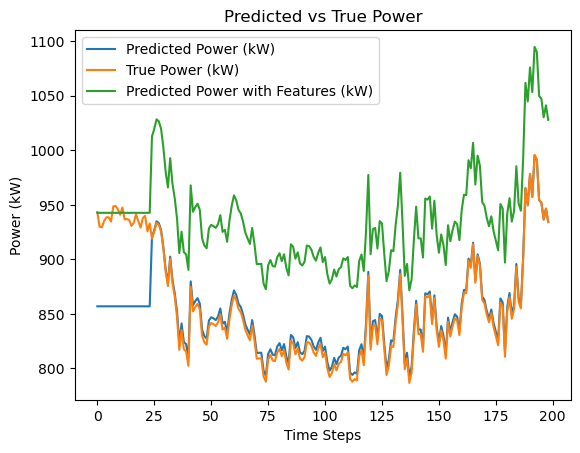

In [179]:
# plot the predictions and the true values
import matplotlib.pyplot as plt
predicted_values = [predictions_for_january[time]['predicted_power_kw'] for time in predictions_for_january]
true_values = [predictions_for_january[time]['true_power_kw'] for time in predictions_for_january]
predicted_values_90 = [predictions_for_january_90[time]['predicted_power_kw'] for time in predictions_for_january_90]
plt.plot(predicted_values, label='Predicted Power (kW)')
plt.plot(true_values, label='True Power (kW)')
plt.plot(predicted_values_90, label='Predicted Power with Features (kW)')
plt.xlabel('Time Steps')
plt.ylabel('Power (kW)')
plt.title('Predicted vs True Power')
plt.legend()
plt.show()

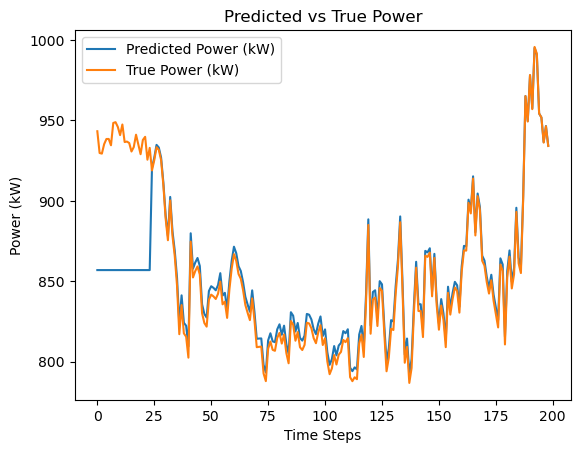

MAE:  13.45605460012983


In [180]:
# predictions_for_january
# plot the predictions and the true values
import matplotlib.pyplot as plt
predicted_values = [predictions_for_january[time]['predicted_power_kw'] for time in predictions_for_january]
true_values = [predictions_for_january[time]['true_power_kw'] for time in predictions_for_january]
plt.plot(predicted_values, label='Predicted Power (kW)')
plt.plot(true_values, label='True Power (kW)')
plt.xlabel('Time Steps')
plt.ylabel('Power (kW)')
plt.title('Predicted vs True Power')
plt.legend()
plt.show()
# the mae score for the predictions
mae = sum([abs(predictions_for_january[time]['predicted_power_kw'] - predictions_for_january[time]['true_power_kw']) for time in predictions_for_january]) / len(predictions_for_january)
print("MAE: ", mae)

In [190]:
torch.save(model.state_dict(), 'generator_model.pth')
#save the csv file with the predictions
prediction = {}
# prediction = {
#     'timestamp': [time for time in predictions_for_january],
#     'pred_power_kw': [predictions_for_january[time]['predicted_power_kw'] for time in predictions_for_january],
#     'pred_p90_kw': [predictions_for_january_90[time]['predicted_power_kw'] for time in predictions_for_january_90]    
# }
import datetime
from collections import defaultdict
from datetime import datetime, timedelta
def parse_decimal(value: str) -> float | None:
    text = value.strip()
    if not text:
        return None
    try:
        return float(text.replace(",", "."))
    except ValueError:
        return None


def parse_timestamp(value: str) -> datetime:
    text = value.strip()
    if text.endswith("Z"):
        text = text[:-1]
    return datetime.fromisoformat(text.replace(" ", "T"))


def to_hour(ts: datetime) -> datetime:
    return ts.replace(minute=0, second=0, microsecond=0)


def iso_utc(ts: datetime) -> str:
    return ts.strftime("%Y-%m-%dT%H:%M:%SZ")
predictions = []
for time in predictions_for_january:
    hour = time.split(' ')[1].split(':')[0]
    pred_power_kw = predictions_for_january[time]['predicted_power_kw']
    pred_p90_kw = predictions_for_january_90[time]['predicted_power_kw']
    predictions.append(
        {
            "timestamp_utc": to_hour(parse_timestamp(time)).isoformat() + "Z",
            "pred_power_kw": round(pred_power_kw, 6),
            "pred_p90_kw": round(pred_p90_kw, 6),
        }
    )
predictions_df = pd.DataFrame(predictions)
predictions_df.to_csv('predictions.csv', index=False)

In [191]:
import pathlib
from pathlib import Path
import csv
OPEN_CSV = Path('predictions.csv')
OUTPUT_CSV = Path('predictions_output.csv')
with OUTPUT_CSV.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["timestamp_utc", "pred_power_kw", "pred_p90_kw"])
    writer.writeheader()
    writer.writerows(predictions)

OUTPUT_CSV

PosixPath('predictions_output.csv')

In [192]:
predictions_df.head()

,timestamp_utc,pred_power_kw,pred_p90_kw
0,2026-01-01T00:00:00Z,856.944214,942.638611
1,2026-01-01T01:00:00Z,856.944214,942.638611
2,2026-01-01T02:00:00Z,856.944214,942.638611
3,2026-01-01T03:00:00Z,856.944214,942.638611
4,2026-01-01T04:00:00Z,856.944214,942.638611


In [97]:
power_kw.shape

(24,)